#### Hi This is my datat analytics project on chocolate sales data set, that I found in kaggle.

#### This project analyzes sales performance for a chocolate company using Python, Pandas, and data visualization techniques. The goal is to uncover meaningful business insights by exploring revenue patterns, product performance, shipping behavior, and customer demand across countries and time periods.

In [86]:
import kagglehub
path = kagglehub.dataset_download("saidaminsaidaxmadov/chocolate-sales")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\X\.cache\kagglehub\datasets\saidaminsaidaxmadov\chocolate-sales\versions\2


In [7]:
import os
os.listdir(r"C:\Users\X\.cache\kagglehub\datasets\saidaminsaidaxmadov\chocolate-sales\versions\2")

['Chocolate Sales (2).csv',
 'ChocolateSales.pbit',
 'ChocolateSales.pbix',
 'ChocolateSales.pdf']

In [75]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\X\.cache\kagglehub\datasets\saidaminsaidaxmadov\chocolate-sales\versions\2\Chocolate Sales (2).csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [11]:
df.shape 
df.info() 
df.columns
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


<bound method NDFrame.describe of           Sales Person    Country              Product        Date  \
0       Jehu Rudeforth         UK      Mint Chip Choco  04/01/2022   
1          Van Tuxwell      India        85% Dark Bars  01/08/2022   
2         Gigi Bohling      India  Peanut Butter Cubes  07/07/2022   
3         Jan Morforth  Australia  Peanut Butter Cubes  27/04/2022   
4       Jehu Rudeforth         UK  Peanut Butter Cubes  24/02/2022   
...                ...        ...                  ...         ...   
3277  Karlen McCaffrey  Australia  Spicy Special Slims  17/05/2024   
3278    Jehu Rudeforth        USA           White Choc  07/06/2024   
3279      Ches Bonnell     Canada  Organic Choco Syrup  26/07/2024   
3280    Dotty Strutley      India              Eclairs  28/07/2024   
3281  Karlen McCaffrey      India       70% Dark Bites  23/05/2024   

          Amount  Boxes Shipped  
0      $5,320.00            180  
1      $7,896.00             94  
2      $4,501.00       

In [13]:
#Cleaning the Data
#From df.describe :  3 Date 3282 non-null object
df['Date']=pd.to_datetime(df['Date'],dayfirst=True, errors='coerce')
df['Date'].dtype
df=df.sort_values('Date')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1012,Dotty Strutley,USA,Raspberry Choco,2022-01-03,"$3,437.00",46
253,Marney O'Breen,Australia,Smooth Sliky Salty,2022-01-03,"$3,745.00",170
89,Andria Kimpton,Canada,Caramel Stuffed Bars,2022-01-03,"$7,154.00",348
187,Dotty Strutley,UK,99% Dark & Pure,2022-01-03,"$9,310.00",282
185,Camilla Castle,UK,White Choc,2022-01-03,"$9,982.00",187


In [15]:
df.isna().sum()
df['Amount'] = df['Amount'].str.replace('$', '', regex=False)
df['Amount'] = df['Amount'].str.replace(',', '', regex=False)
df['Amount'].str.strip()
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%B') 
df['Quarter'] = df['Date'].dt.quarter

df.head()



,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,MonthName,Quarter
1012,Dotty Strutley,USA,Raspberry Choco,2022-01-03,3437.0,46,2022,1,January,1
253,Marney O'Breen,Australia,Smooth Sliky Salty,2022-01-03,3745.0,170,2022,1,January,1
89,Andria Kimpton,Canada,Caramel Stuffed Bars,2022-01-03,7154.0,348,2022,1,January,1
187,Dotty Strutley,UK,99% Dark & Pure,2022-01-03,9310.0,282,2022,1,January,1
185,Camilla Castle,UK,White Choc,2022-01-03,9982.0,187,2022,1,January,1


In [19]:
df['Amount'].dtype
df[df['Amount'].isna()]


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,MonthName,Quarter


#### Following are few trends in the data


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Date'>

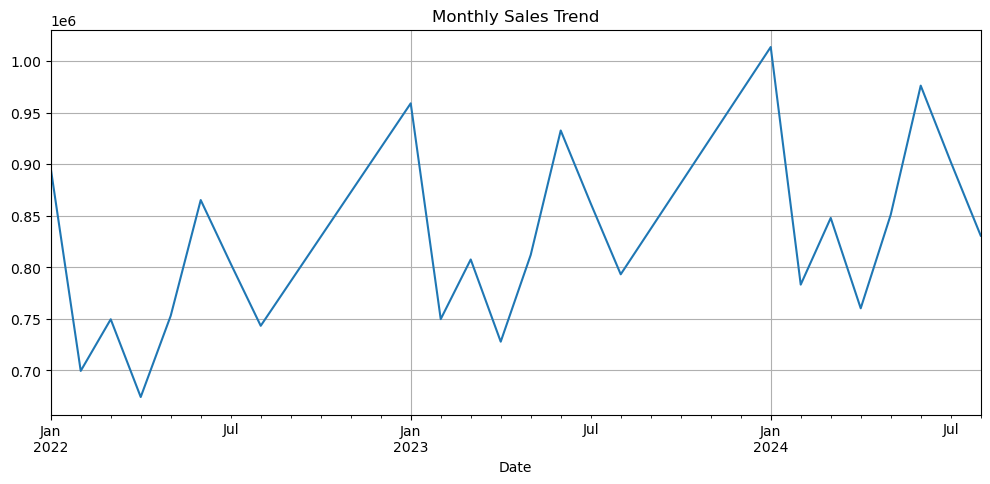

In [21]:
# Following are few trends in the data
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', figsize=(12,5), title='Monthly Sales Trend', grid='on')


<Axes: title={'center': 'Sales by Country'}, xlabel='Country'>

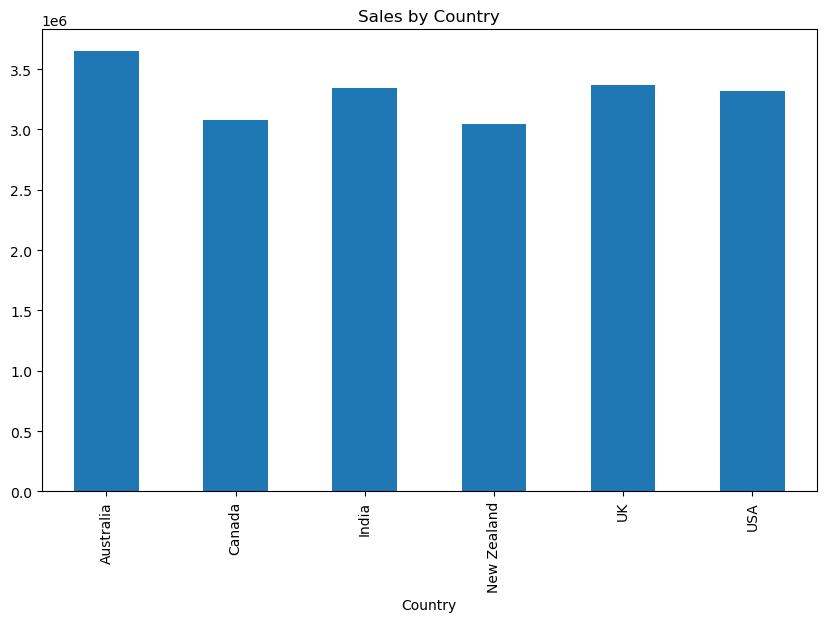

In [22]:
sale_country= df.groupby('Country')['Amount'].sum()
sale_country.plot(kind='bar',figsize=(10,6), title='Sales by Country')

In [23]:
df.head()
df['Product'].nunique()

22

#### Most income generating products


<Axes: title={'center': 'Products by income'}, xlabel='Product'>

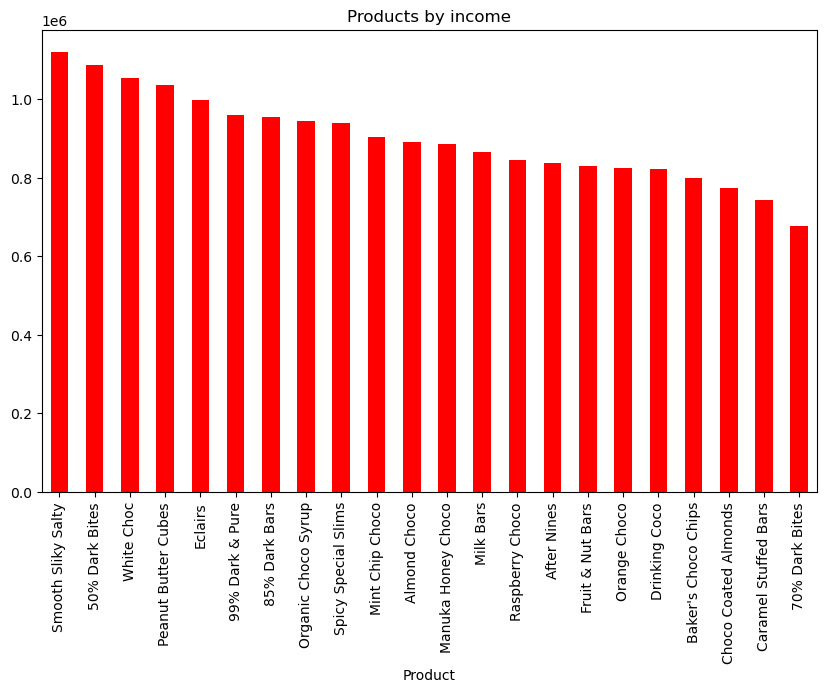

In [24]:
products=df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
products.plot(kind='bar', figsize=(10,6),color='red',title='Products by income')

<Axes: xlabel='Boxes Shipped', ylabel='Amount'>

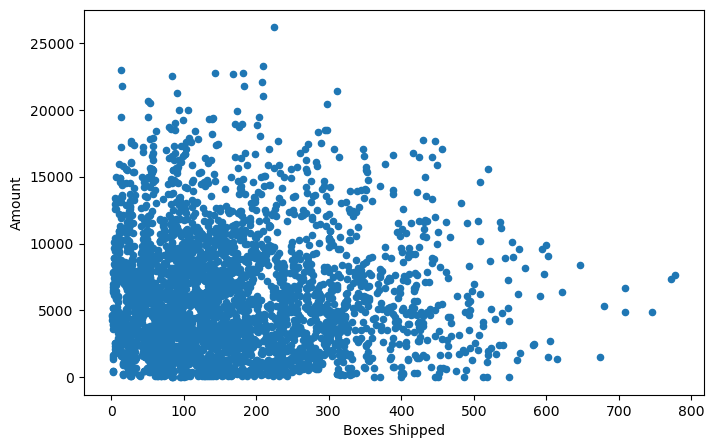

In [73]:
df.plot(kind='scatter', x='Boxes Shipped', y='Amount', figsize=(8,5))

#### There is no linear relation btw amount and boxes shipped. Hence a regression model is not fit here.

In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df[['Amount', 'Boxes Shipped']] 

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_

In [49]:
df.groupby('Cluster')[['Amount', 'Boxes Shipped']].mean()
cluster_labels = {
    0: "Low Revenue / Low Volume",
    1: "High Revenue / High Volume",
    2: "High Revenue / Low Volume"
}
df['ClusterLabel'] = df['Cluster'].map(cluster_labels)


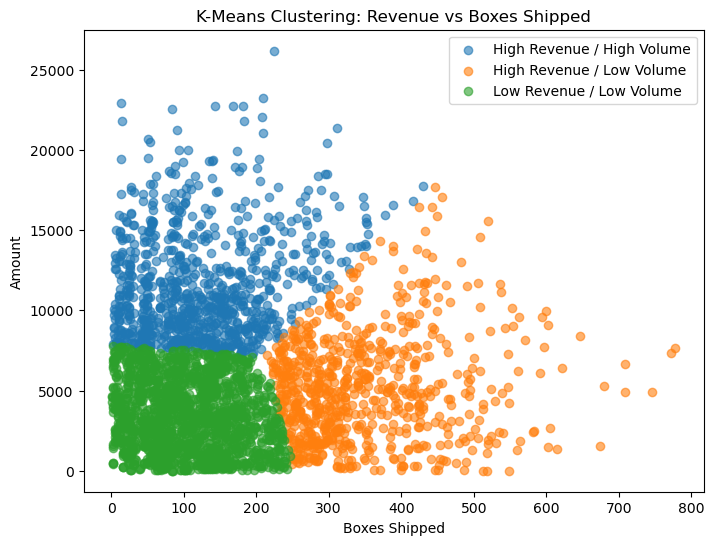

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label, group in df.groupby('ClusterLabel'):
    plt.scatter(
        group['Boxes Shipped'],
        group['Amount'],
        label=label,
        alpha=0.6
    )

plt.xlabel('Boxes Shipped')
plt.ylabel('Amount')
plt.title('K-Means Clustering: Revenue vs Boxes Shipped')
plt.legend()
plt.show()

In [61]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,MonthName,Quarter,Cluster,RevenuePerBox,ClusterLabel
1012,Dotty Strutley,USA,Raspberry Choco,2022-01-03,3437.0,46,2022,1,January,1,0,74.717391,Low Revenue / Low Volume
253,Marney O'Breen,Australia,Smooth Sliky Salty,2022-01-03,3745.0,170,2022,1,January,1,0,22.029412,Low Revenue / Low Volume
89,Andria Kimpton,Canada,Caramel Stuffed Bars,2022-01-03,7154.0,348,2022,1,January,1,2,20.557471,High Revenue / Low Volume
187,Dotty Strutley,UK,99% Dark & Pure,2022-01-03,9310.0,282,2022,1,January,1,2,33.014184,High Revenue / Low Volume
185,Camilla Castle,UK,White Choc,2022-01-03,9982.0,187,2022,1,January,1,1,53.379679,High Revenue / High Volume


In [67]:
inertia = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)


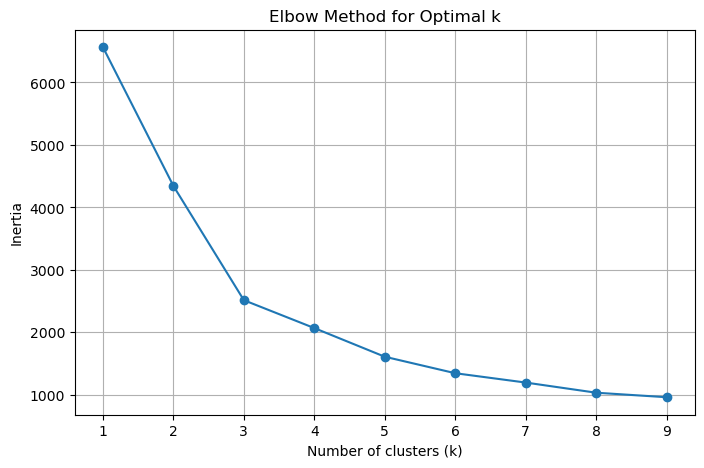

In [71]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()


#### The elbow method shows a clear bend at k = 3, indicating that three clusters provide the best balance between model simplicity and cluster compactness. Increasing k beyond 3 yields diminishing returns, so k = 3 was selected as the optimal number of clusters.

#### Next Steps 
##### Build a time‑series forecast to predict future sales trends
##### Develop an interactive dashboard using Plotly, Power BI, or Tableau